In [91]:
import numpy as np 
import matplotlib.pyplot as pt
import os
view = np.load("resised_pixels_final.npy") #Loading the new resized pixel values
print(view)
print(view.shape)
categories = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Y_list = []
m = view.shape[0] #Total number of images
for label_idx, folder_name in enumerate(categories):
    folder_path = os.path.join("flowers", folder_name)
    for _ in os.listdir(folder_path):
        Y_list.append(label_idx)

Y_all = np.array(Y_list)

# 3. Shuffle images and labels together
permutation = np.random.permutation(m)
view_shuffled = view[permutation]
Y_shuffled = Y_all[permutation]

# 4. Normalize and transpose feature matrix: Shape (3072, 4317)
X_all = (view_shuffled.reshape(m, -1) / 255.0).T

[[[[144 145 145]
   [170 162 163]
   [177 169 169]
   ...
   [171 169 168]
   [168 164 164]
   [151 154 154]]

  [[122 130 131]
   [153 151 151]
   [180 176 174]
   ...
   [174 169 170]
   [160 157 157]
   [148 150 150]]

  [[107 114 117]
   [142 141 141]
   [153 151 151]
   ...
   [161 156 157]
   [157 157 157]
   [120 124 125]]

  ...

  [[ 13  30  27]
   [ 69  72  72]
   [137 131 133]
   ...
   [126 128 128]
   [136 132 133]
   [138 136 136]]

  [[ 18  39  36]
   [ 79  84  83]
   [122 121 121]
   ...
   [130 134 135]
   [120 123 127]
   [116 121 124]]

  [[ 26  47  44]
   [ 45  58  57]
   [114 113 117]
   ...
   [134 136 138]
   [133 134 138]
   [125 126 130]]]


 [[[231 226 223]
   [227 225 218]
   [240 236 230]
   ...
   [ 18  14   8]
   [ 25  25  20]
   [ 15  12  13]]

  [[238 234 230]
   [242 236 231]
   [236 232 233]
   ...
   [ 24  20  18]
   [ 40  56  42]
   [ 15  15  10]]

  [[243 239 228]
   [240 234 230]
   [241 237 232]
   ...
   [ 25  26   9]
   [ 26  23  20]
   [ 18  19

In [92]:
#Extract the number of images 
m = view.shape[0] 

#Shuffle your raw images safely before flattening
np.random.shuffle(view)

#Flatten the matrix 
flattend_matrix = view.reshape(m, -1)

#Transpose so columns are individual images
transposed_matrix = flattend_matrix.T

#Extract features for validation and training
X_aside = transposed_matrix[:, :1500] 
X_train = transposed_matrix[:, 1500:]
Y_train = Y_shuffled[1500:]
Y_aside = Y_shuffled[0:1500]
#Keep a visual data subset sample
data_train = transposed_matrix[:, 1500:m] 

print("X_aside shape:", X_aside.shape)
print("X_train shape:", X_train.shape)
print(X_train[:,0].shape)

flower_map = {"daisy":0,"dandelion":1,"rose":2,"sunflower":3,"tulip":4}


X_aside shape: (3072, 1500)
X_train shape: (3072, 2817)
(3072,)


In [93]:
def parameters():
    W1 = np.random.randn(128,3072) * np.sqrt(2.0/3072)#He Kamping initialization
    b1 = np.zeros((128,1))
    W2 = np.random.randn(5,128)* np.sqrt(2.0/64) #He initialization
    b2 = np.zeros((5,1))
    return W1,b1,W2,b2

def ReLu(Z):
    return np.maximum(Z>0,Z,0.01*Z)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_prop(W1,W2,b1,b2,X):
    Z1 = W1.dot(X) + b1
    A1 = ReLu(Z1) 
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1,A1,Z2,A2

def hot_encoding(Y):
    one_hot_Y = np.zeros((Y.size,5)) #Because we have 5 labels
    one_hot_Y[np.arange(Y.size),Y.astype(int)] = 1
    return one_hot_Y.T

def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size  # Total number of training samples
    one_hot_Y = hot_encoding(Y)
    
    # Layer 2 Gradients 
    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    # Layer 1 Gradients 
    dZ1 = np.dot(W2.T, dZ2) * derivative_ReLU(Z1)  # (Z1 > 0) is the derivative of ReLU
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)    
    return dW1, db1, dW2, db2

def derivative_ReLU(Z):
    return np.where(Z > 0, 1.0, 0.01)
    
    

def updated_parameters(W1,b1,W2,b2,dW1,db1,dW2,db2,alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1,b1,W2,b2


C:\Users\aarya\AppData\Local\Temp\ipykernel_2688\3602720059.py:9: DeprecationWarning: Passing more than 2 positional arguments to np.maximum and np.minimum is deprecated. If you meant to use the third argument as an output, use the `out` keyword argument instead. If you hoped to work with more than 2 inputs, combine them into a single array and get the extrema for the relevant axis.
  return np.maximum(Z>0,Z,0.01*Z)


[0 0 0 ... 0 0 0] [0 1 4 ... 4 4 4]
Iteration   0 | Training Accuracy: 18.25%
[4 4 4 ... 4 4 4] [0 1 4 ... 4 4 4]
Iteration  10 | Training Accuracy: 22.79%
[4 4 4 ... 4 4 4] [0 1 4 ... 4 4 4]
Iteration  20 | Training Accuracy: 22.79%
[4 4 4 ... 4 4 4] [0 1 4 ... 4 4 4]
Iteration  30 | Training Accuracy: 22.79%
[4 4 4 ... 4 4 4] [0 1 4 ... 4 4 4]
Iteration  40 | Training Accuracy: 22.79%


C:\Users\aarya\AppData\Local\Temp\ipykernel_2688\359653197.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pt.legend()


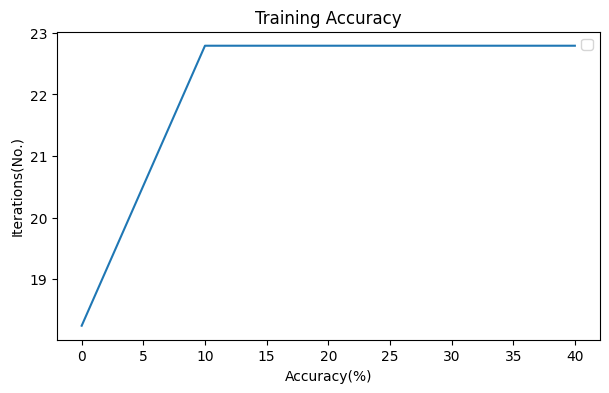

In [ ]:
import matplotlib.pyplot as pt

def get_predictions(A2):
    return np.argmax(A2,0)

def get_accuracy(predictions,Y):
    print(predictions,Y)
    return np.sum(predictions == Y) / Y.size



#The function which actually runs the training of the model
def grad_descent(X,Y,alpha,iterations):
    accuracy_history = []
    iteration_history = []
    W1,b1,W2,b2 = parameters()
    for i in range(iterations):
        Z1,A1,Z2,A2 = forward_prop(W1,W2,b1, b2, X)
        dW1,db1,dW2,db2 = back_prop(Z1, A1, Z2, A2,W1, W2, X, Y)
        W1,b1,W2,b2 = updated_parameters(W1,b1,W2,b2,dW1,db1,dW2,db2,alpha)
        if i % 10 == 0:
                    predictions = get_predictions(A2)
                    acc = get_accuracy(predictions, Y)
                    print(f"Iteration {i:3d} | Training Accuracy: {acc * 100:.2f}%")
                    accuracy_history.append(acc*100)
                    iteration_history.append(i)
    return W1,b1,W2,b2,iteration_history,accuracy_history

#Calling the training function

W1, b1, W2, b2, iteration_history, accuracy_history = grad_descent(
    X_train, Y_train, alpha=0.05, iterations=50
)
import matplotlib.pyplot as pt
pt.figure(figsize=(7, 4))
pt.plot(iteration_history,accuracy_history)
pt.xlabel("Iteration(In numbers)")
pt.ylabel("Accuracy(%)")
pt.title("Training Accuracy")
pt.legend()
pt.show()

    

NameError: name 'accuracy' is not defined